# NVDA Volatility Crush Pilot

**Objective:** Test the ML-powered volatility crush strategy end-to-end on NVDA earnings events.  
**Strategy:** Identify high pre-earnings IV, predict whether selling a straddle is profitable, backtest.  
**Data:** Alpha Vantage historical options + existing earnings features from the pipeline.

In [1]:
# ── Cell 1: Setup & Config ──────────────────────────────────────────────────
import os, sys, warnings, json, time, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
PROJECT_ROOT = Path('..').resolve()
PILOT_DATA   = Path('pilot_data')
CACHE_DIR    = Path('cache')
PILOT_DATA.mkdir(exist_ok=True)
(PILOT_DATA / 'models').mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

# API key
load_dotenv(PROJECT_ROOT / '.env')
AV_API_KEY = os.getenv('ALPHA_VANTAGE_API')
print(f'Alpha Vantage key loaded: {"YES" if AV_API_KEY else "NO"}')

# Utils
from vol_crush_utils import (
    THEME, setup_theme, style_axis,
    load_and_dedup_earnings, get_trading_day_offset,
    fetch_historical_options, extract_atm_options,
    compute_straddle_metrics, black_scholes_price, implied_vol,
    build_vol_features, compute_realized_vol,
    sharpe_ratio, max_drawdown, calmar_ratio, profit_factor, win_rate,
)

setup_theme()
print('Theme applied. Ready.')

Alpha Vantage key loaded: YES
Theme applied. Ready.


In [2]:
# ── Cell 2: Load & Dedup NVDA Earnings Events ───────────────────────────────
OUT_01 = PILOT_DATA / '01_nvda_earnings_events.csv'

if OUT_01.exists():
    events = pd.read_csv(OUT_01)
    print(f'Loaded from {OUT_01} ({len(events)} rows)')
else:
    raw = load_and_dedup_earnings(PROJECT_ROOT / 'data' / 'raw' / 'NVDA.csv')
    events = raw[[
        'symbol', 'date', 'year', 'quarter', 'announcement_date',
        'eps_actual', 'revenue_actual', 'beat',
    ]].copy()
    events.to_csv(OUT_01, index=False)
    print(f'Saved to {OUT_01} ({len(events)} rows)')

print(f'\nNVDA earnings events: {len(events)} unique (2017-2025)')
events.head(10)

Loaded from pilot_data/01_nvda_earnings_events.csv (26 rows)

NVDA earnings events: 26 unique (2017-2025)


,symbol,date,year,quarter,announcement_date,eps_actual,revenue_actual,beat
0,NVDA,2017-07-31,2017,3,2017-11-09,0.03,2.636000e+09,1.0
1,NVDA,2017-10-31,2017,4,2018-02-08,0.04,2.911000e+09,1.0
2,NVDA,2018-04-30,2018,2,2018-08-16,0.05,3.123000e+09,1.0
3,NVDA,2018-07-31,2018,3,2018-11-15,0.05,3.181000e+09,1.0
4,NVDA,2018-10-31,2018,4,2019-02-14,0.02,2.205000e+09,1.0
5,NVDA,2019-04-30,2019,2,2019-08-15,0.03,2.579000e+09,1.0
6,NVDA,2019-07-31,2019,3,2019-11-14,0.04,3.014000e+09,1.0
7,NVDA,2019-10-31,2019,4,2020-02-13,0.05,3.105000e+09,1.0
8,NVDA,2020-04-30,2020,2,2020-08-19,0.05,3.866000e+09,1.0
9,NVDA,2020-07-31,2020,3,2020-11-18,0.07,4.726000e+09,1.0


In [3]:
# ── Cell 3: Extract Existing ML Features for NVDA ───────────────────────────
OUT_02 = PILOT_DATA / '02_nvda_earnings_features.csv'

if OUT_02.exists():
    earnings_features = pd.read_csv(OUT_02)
    print(f'Loaded from {OUT_02} ({len(earnings_features)} rows, {earnings_features.shape[1]} cols)')
else:
    ml_ready = PROJECT_ROOT / 'data' / 'ml_ready'
    feat = pd.read_csv(ml_ready / 'sp500_features.csv')
    meta = pd.read_csv(ml_ready / 'sp500_metadata.csv')
    tgt  = pd.read_csv(ml_ready / 'sp500_target.csv')

    full = pd.concat([meta, feat, tgt], axis=1)
    nvda = full[full['symbol'] == 'NVDA'].copy()
    nvda = nvda.drop_duplicates(subset=['date', 'announcement_date'], keep='first')
    nvda = nvda.sort_values('date').reset_index(drop=True)

    earnings_features = nvda
    earnings_features.to_csv(OUT_02, index=False)
    print(f'Saved to {OUT_02} ({len(earnings_features)} rows, {earnings_features.shape[1]} cols)')

print(f'Feature columns: {earnings_features.shape[1] - 4}')  # minus metadata cols
earnings_features.head()

Loaded from pilot_data/02_nvda_earnings_features.csv (26 rows, 56 cols)
Feature columns: 52


,symbol,date,announcement_date,year,beat_rate_8q,beat_streak_4q,eps_estimate_30d_ago,eps_estimate_60d_ago,eps_estimate_7d_ago,eps_estimate_90d_ago,...,price_change_5d_pct,price_change_60d_pct,quarter,quarter_cos,quarter_sin,revision_down_30d,revision_down_7d,revision_up_30d,revision_up_7d,beat
0,NVDA,2017-07-31,2017-11-09,2017,0.875,0.0,0.017250,0.01725,0.017250,0.017000,...,0.225209,27.778118,3,-1.836970e-16,-1.000000e+00,1.0,0.0,4.0,1.0,1
1,NVDA,2017-10-31,2018-02-08,2017,0.875,1.0,0.041322,0.04118,0.041363,0.040895,...,-2.021239,19.484005,4,1.000000e+00,-2.449294e-16,0.0,0.0,6.0,4.0,1
2,NVDA,2018-04-30,2018-08-16,2018,1.000,3.0,0.036250,0.03625,0.036250,0.024500,...,1.683728,-2.329778,2,-1.000000e+00,1.224647e-16,1.0,0.0,1.0,0.0,1
3,NVDA,2018-07-31,2018-11-15,2018,1.000,4.0,0.041500,0.04175,0.041500,0.041750,...,-4.123096,-28.665460,3,-1.836970e-16,-1.000000e+00,1.0,0.0,4.0,3.0,1
4,NVDA,2018-10-31,2019-02-14,2018,1.000,4.0,0.041322,0.04118,0.041363,0.040895,...,3.178793,4.390585,4,1.000000e+00,-2.449294e-16,0.0,0.0,6.0,4.0,1


In [4]:
# ── Cell 4: Fetch Historical Options from Alpha Vantage ─────────────────────
OUT_03 = PILOT_DATA / '03_options_chains_raw.csv'

if OUT_03.exists():
    options_raw = pd.read_csv(OUT_03)
    print(f'Loaded from {OUT_03} ({len(options_raw)} rows)')
else:
    all_chains = []
    for idx, ev in events.iterrows():
        ann = ev['announcement_date']
        pre_date  = get_trading_day_offset(ann, -2)
        post_date = get_trading_day_offset(ann, +1)

        for fetch_date, label in [(pre_date, 'pre'), (post_date, 'post')]:
            print(f"  [{idx+1}/{len(events)}] {ann} -> {label}: {fetch_date}", end=' ')
            chain = fetch_historical_options('NVDA', fetch_date, AV_API_KEY, CACHE_DIR)
            if chain is not None and not chain.empty:
                chain['event_date'] = ev['date']
                chain['announcement_date'] = ann
                chain['position'] = label
                all_chains.append(chain)
                print(f'({len(chain)} contracts)')
            else:
                print('(no data)')

    if all_chains:
        options_raw = pd.concat(all_chains, ignore_index=True)
    else:
        options_raw = pd.DataFrame()

    options_raw.to_csv(OUT_03, index=False)
    print(f'\nSaved to {OUT_03} ({len(options_raw)} rows)')

print(f'\nTotal option contracts: {len(options_raw)}')
if not options_raw.empty:
    print(f'Events with data: {options_raw["announcement_date"].nunique()}')
    print(f'Columns: {list(options_raw.columns)}')

Loaded from pilot_data/03_options_chains_raw.csv (158898 rows)

Total option contracts: 158898
Events with data: 26
Columns: ['contractID', 'symbol', 'expiration', 'strike', 'type', 'last', 'mark', 'bid', 'bid_size', 'ask', 'ask_size', 'volume', 'open_interest', 'date', 'implied_volatility', 'delta', 'gamma', 'theta', 'vega', 'rho', 'fetch_date', 'event_date', 'announcement_date', 'position']


In [5]:
# ── Cell 5: Compute IV & Straddle Metrics ──────────────────────────────────
from vol_crush_utils import estimate_stock_price_from_chain

OUT_04 = PILOT_DATA / '04_iv_straddle_metrics.csv'

if OUT_04.exists():
    iv_metrics = pd.read_csv(OUT_04)
    print(f'Loaded from {OUT_04} ({len(iv_metrics)} rows)')
else:
    r = 0.05
    rows = []

    for _, ev in events.iterrows():
        ann = ev['announcement_date']
        ev_date = ev['date']
        row = {'date': ev_date, 'announcement_date': ann, 'year': ev['year']}

        for position in ['pre', 'post']:
            mask = (
                (options_raw['announcement_date'] == ann) &
                (options_raw['position'] == position)
            )
            chain = options_raw[mask]
            if chain.empty:
                continue

            # Estimate stock price from put-call parity
            stock_price = estimate_stock_price_from_chain(chain)
            if stock_price is None or stock_price <= 0:
                continue

            row[f'stock_price_{position}'] = stock_price

            atm = extract_atm_options(chain, stock_price)
            if atm is None:
                continue

            straddle = compute_straddle_metrics(atm['call'], atm['put'], stock_price)
            row[f'straddle_price_{position}'] = straddle['straddle_price']
            row[f'straddle_pct_{position}'] = straddle['straddle_pct']

            # Use AV-provided IV if available, else compute via BS inversion
            for opt_type in ['call', 'put']:
                opt = atm[opt_type]
                av_iv = pd.to_numeric(opt.get('implied_volatility', np.nan), errors='coerce')
                if pd.notna(av_iv) and av_iv > 0:
                    row[f'iv_{opt_type}_{position}'] = av_iv
                else:
                    strike = pd.to_numeric(opt.get('strike', np.nan), errors='coerce')
                    price = straddle[f'{opt_type}_price']
                    exp_str = opt.get('expiration', None)
                    fetch_str = opt.get('fetch_date', ann)
                    if exp_str:
                        T = max((pd.Timestamp(exp_str) - pd.Timestamp(fetch_str)).days / 365, 1/365)
                    else:
                        T = 30 / 365
                    iv_val = implied_vol(price, stock_price, strike, T, r, opt_type)
                    row[f'iv_{opt_type}_{position}'] = iv_val

            # Average IV
            c_iv = row.get(f'iv_call_{position}')
            p_iv = row.get(f'iv_put_{position}')
            if c_iv is not None and p_iv is not None:
                row[f'iv_avg_{position}'] = (c_iv + p_iv) / 2
            elif c_iv is not None:
                row[f'iv_avg_{position}'] = c_iv
            elif p_iv is not None:
                row[f'iv_avg_{position}'] = p_iv

        # IV crush
        if 'iv_avg_pre' in row and 'iv_avg_post' in row:
            pre_iv = row.get('iv_avg_pre')
            post_iv = row.get('iv_avg_post')
            if pre_iv and pre_iv > 0 and post_iv is not None:
                row['iv_crush_pct'] = ((pre_iv - post_iv) / pre_iv) * 100

        rows.append(row)

    iv_metrics = pd.DataFrame(rows)
    iv_metrics.to_csv(OUT_04, index=False)
    print(f'Saved to {OUT_04} ({len(iv_metrics)} rows)')

# Summary
key_cols = ['announcement_date', 'year', 'stock_price_pre', 'iv_avg_pre',
            'straddle_pct_pre', 'iv_avg_post', 'iv_crush_pct']
existing = [c for c in key_cols if c in iv_metrics.columns]
iv_metrics[existing].head(10)

Loaded from pilot_data/04_iv_straddle_metrics.csv (26 rows)


,announcement_date,year,stock_price_pre,iv_avg_pre,straddle_pct_pre,iv_avg_post,iv_crush_pct
0,2017-11-09,2017,212.5,1.024610,7.400000,0.307550,69.983701
1,2018-02-08,2017,225.0,1.151435,8.366667,0.546575,52.530972
2,2018-08-16,2018,262.5,0.819735,5.923810,0.302675,63.076482
3,2018-11-15,2018,200.0,1.448990,10.462500,0.512430,64.635367
4,2019-02-14,2018,150.0,1.029490,7.483333,0.375840,63.492603
5,2019-08-15,2019,155.0,0.980705,7.129032,0.366090,62.670732
6,2019-11-14,2019,210.0,0.941680,6.821429,0.361210,61.641959
7,2020-02-13,2019,267.5,0.995340,7.177570,0.297800,70.080575
8,2020-08-19,2020,495.0,0.809980,6.772727,0.409990,49.382701
9,2020-11-18,2020,540.0,0.844125,7.069444,0.414865,50.852658


In [6]:
# ── Cell 6: Realized Volatility Features ───────────────────────────────────
OUT_05 = PILOT_DATA / '05_vol_features.csv'

if OUT_05.exists():
    vol_features = pd.read_csv(OUT_05)
    print(f'Loaded from {OUT_05} ({len(vol_features)} rows)')
else:
    # Fetch NVDA price history (cache it)
    price_cache = CACHE_DIR / 'NVDA_prices.csv'
    if price_cache.exists():
        prices = pd.read_csv(price_cache)
        print(f'Price history loaded from cache ({len(prices)} days)')
    else:
        import yfinance as yf
        ticker = yf.Ticker('NVDA')
        prices = ticker.history(start='2016-01-01', end='2026-03-01')
        prices = prices.reset_index()
        prices['Date'] = prices['Date'].dt.strftime('%Y-%m-%d')
        prices.to_csv(price_cache, index=False)
        print(f'Price history fetched and cached ({len(prices)} days)')

    vol_features = build_vol_features(events, prices)
    vol_features.to_csv(OUT_05, index=False)
    print(f'Saved to {OUT_05} ({len(vol_features)} rows)')

vol_features.head()

Loaded from pilot_data/05_vol_features.csv (26 rows)


,date,announcement_date,stock_price_pre,stock_price_post,actual_move_pct,realized_vol_5d,realized_vol_21d,realized_vol_63d,vol_of_vol,vol_expansion_ratio,historical_move_avg
0,2017-07-31,2017-11-09,5.167477,5.339923,3.337146,0.182889,0.193393,0.326643,0.061797,0.945686,NaN
1,2017-10-31,2018-02-08,5.656626,5.737717,1.433565,0.844108,0.449059,0.401617,0.051935,1.879726,3.337146
2,2018-04-30,2018-08-16,6.413184,6.060195,5.504111,0.199076,0.186333,0.241176,0.050788,1.068389,2.385355
3,2018-07-31,2018-11-15,4.883849,4.072475,16.613408,0.769064,0.735162,0.542374,0.099981,1.046115,3.424940
4,2018-10-31,2019-02-14,3.790200,3.900773,2.917334,0.410517,0.710850,0.789751,0.104605,0.577502,6.722057


Loaded from pilot_data/06_full_feature_matrix.csv (26 rows, 81 cols)

Feature matrix shape: (26, 81)


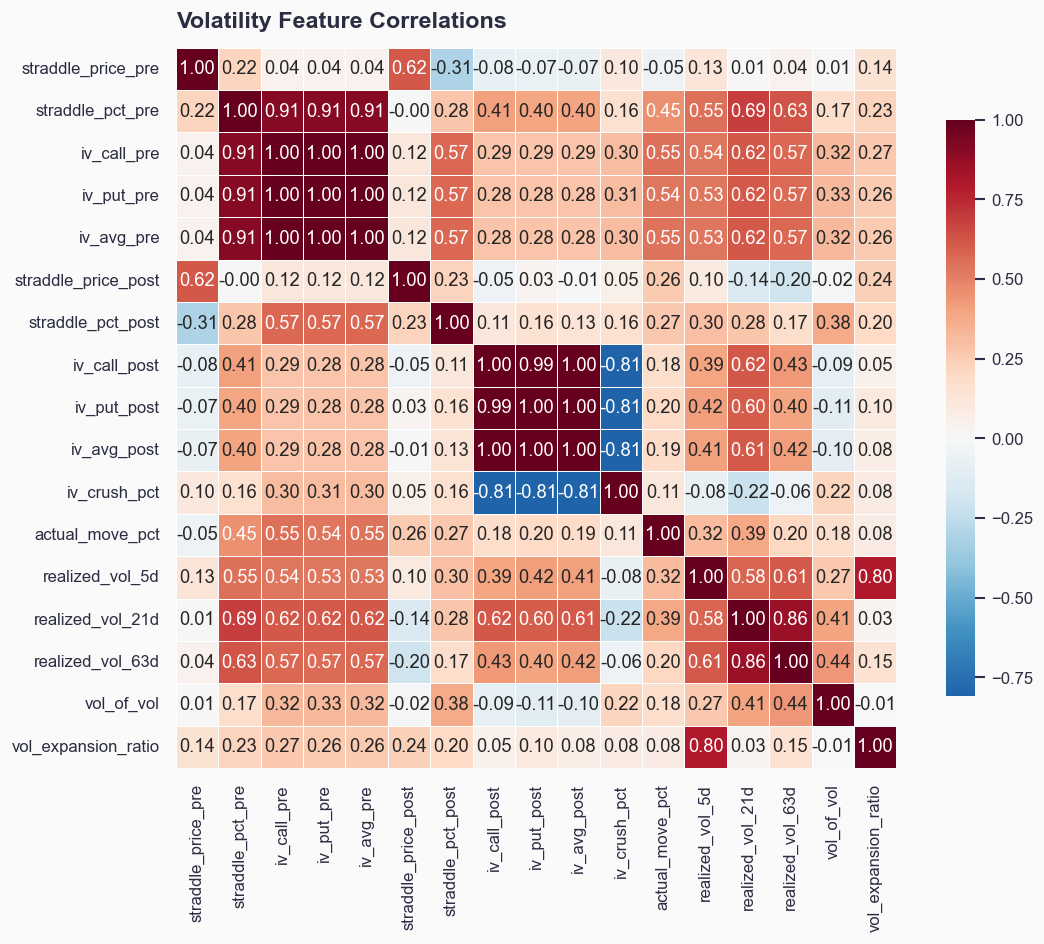

In [7]:
# ── Cell 7: Merge All Features ─────────────────────────────────────────────
OUT_06 = PILOT_DATA / '06_full_feature_matrix.csv'

if OUT_06.exists():
    feature_matrix = pd.read_csv(OUT_06)
    print(f'Loaded from {OUT_06} ({len(feature_matrix)} rows, {feature_matrix.shape[1]} cols)')
else:
    base = events.copy()

    # Merge earnings features (from sp500 ML-ready data)
    ef = earnings_features.copy()
    ef_feature_cols = [c for c in ef.columns if c not in ['symbol', 'date', 'announcement_date', 'year', 'beat']]
    ef_merge = ef[['date'] + ef_feature_cols]
    base = base.merge(ef_merge, on='date', how='left', suffixes=('', '_ef'))

    # Merge IV metrics
    iv_cols = [c for c in iv_metrics.columns if c not in ['date', 'announcement_date', 'year']]
    iv_merge = iv_metrics[['date'] + iv_cols]
    base = base.merge(iv_merge, on='date', how='left', suffixes=('', '_iv'))

    # Merge vol features
    vf_cols = [c for c in vol_features.columns if c not in ['date', 'announcement_date']]
    vf_merge = vol_features[['date'] + vf_cols]
    base = base.merge(vf_merge, on='date', how='left', suffixes=('', '_vf'))

    feature_matrix = base
    feature_matrix.to_csv(OUT_06, index=False)
    print(f'Saved to {OUT_06} ({len(feature_matrix)} rows, {feature_matrix.shape[1]} cols)')

print(f'\nFeature matrix shape: {feature_matrix.shape}')

# Correlation of new vol features with each other
vol_cols = [c for c in feature_matrix.columns if any(
    s in c for s in ['iv_', 'straddle_', 'realized_vol', 'vol_of_vol', 'vol_expansion', 'actual_move']
)]
if len(vol_cols) > 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    corr = feature_matrix[vol_cols].corr()
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        ax=ax, square=True, linewidths=0.5,
        cbar_kws={'shrink': 0.8}
    )
    style_axis(ax, title='Volatility Feature Correlations')
    plt.tight_layout()
    plt.show()

Loaded from pilot_data/07_labeled_dataset.csv (26 rows)

Class balance (crush_profitable):
crush_profitable
1    23
0     3
Name: count, dtype: int64
Positive rate: 88.5%


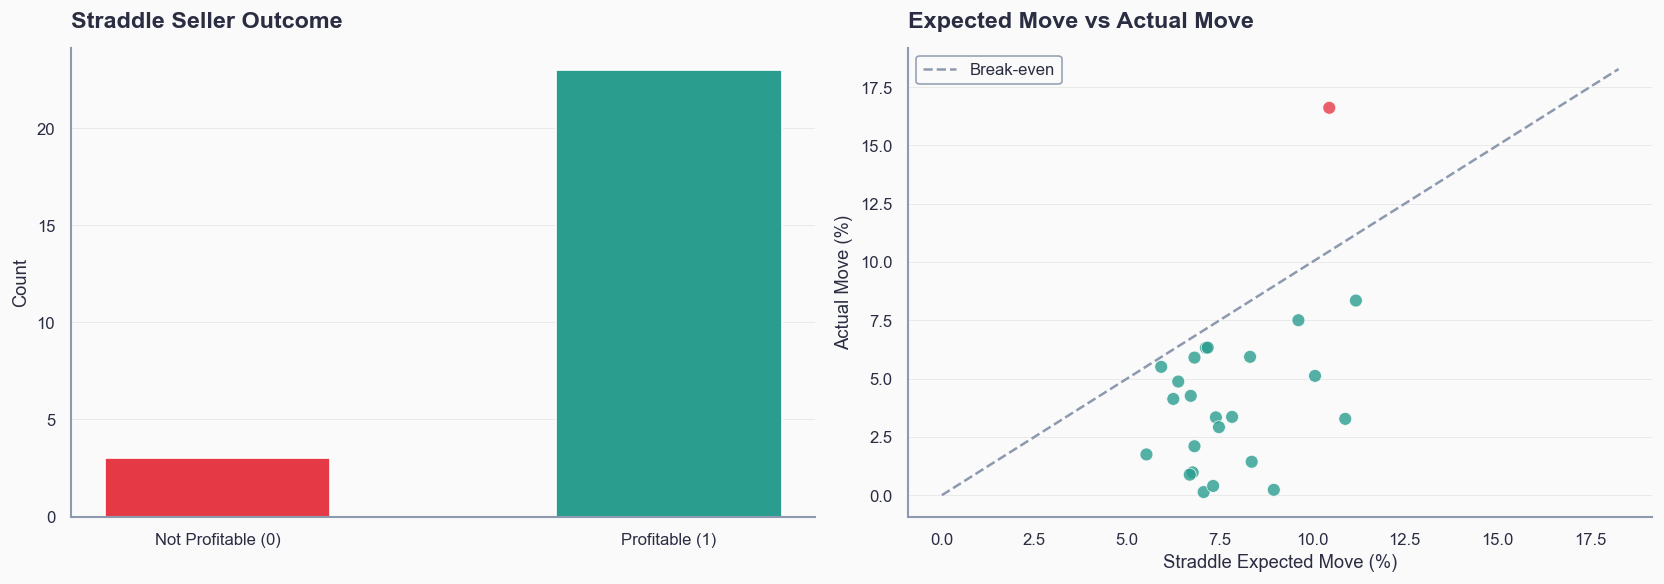

In [8]:
# ── Cell 8: Target Definition & Labeled Dataset ────────────────────────────
OUT_07 = PILOT_DATA / '07_labeled_dataset.csv'

if OUT_07.exists():
    labeled = pd.read_csv(OUT_07)
    print(f'Loaded from {OUT_07} ({len(labeled)} rows)')
else:
    labeled = feature_matrix.copy()

    # Straddle P&L: if actual move < straddle expected move -> seller profits
    if 'straddle_pct_pre' in labeled.columns and 'actual_move_pct' in labeled.columns:
        labeled['crush_profitable'] = (
            labeled['actual_move_pct'] < labeled['straddle_pct_pre']
        ).astype(int)
        labeled['crush_pnl_pct'] = labeled['straddle_pct_pre'] - labeled['actual_move_pct']
    else:
        # Fallback if options data unavailable: use price move magnitude
        labeled['crush_profitable'] = np.nan
        labeled['crush_pnl_pct'] = np.nan
        print('WARNING: straddle/move data missing, target may be incomplete')

    labeled.to_csv(OUT_07, index=False)
    print(f'Saved to {OUT_07} ({len(labeled)} rows)')

# EDA
if 'crush_profitable' in labeled.columns and labeled['crush_profitable'].notna().sum() > 0:
    valid = labeled.dropna(subset=['crush_profitable'])
    print(f'\nClass balance (crush_profitable):')
    print(valid['crush_profitable'].value_counts())
    print(f'Positive rate: {valid["crush_profitable"].mean():.1%}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart of class balance
    counts = valid['crush_profitable'].value_counts().sort_index()
    colors = [THEME['negative'], THEME['positive']]
    axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Not Profitable (0)', 'Profitable (1)'])
    style_axis(axes[0], title='Straddle Seller Outcome', ylabel='Count')

    # Scatter: expected move vs actual move
    if 'straddle_pct_pre' in valid.columns:
        c = valid['crush_profitable'].map({1: THEME['positive'], 0: THEME['negative']})
        axes[1].scatter(
            valid['straddle_pct_pre'], valid['actual_move_pct'],
            c=c, s=60, edgecolors='white', linewidth=0.5, alpha=0.8
        )
        lim = max(valid['straddle_pct_pre'].max(), valid['actual_move_pct'].max()) * 1.1
        axes[1].plot([0, lim], [0, lim], '--', color=THEME['neutral'], lw=1.5, label='Break-even')
        axes[1].legend()
        style_axis(axes[1], title='Expected Move vs Actual Move',
                   xlabel='Straddle Expected Move (%)', ylabel='Actual Move (%)')

    plt.tight_layout()
    plt.show()
else:
    print('No valid crush target data to visualize.')

In [9]:
# ── Cell 9: Temporal Train / Val / Test Split ──────────────────────────────
OUT_08 = PILOT_DATA / '08_train_val_test_split.csv'

if OUT_08.exists():
    split_df = pd.read_csv(OUT_08)
    print(f'Loaded from {OUT_08} ({len(split_df)} rows)')
else:
    split_df = labeled.copy()
    split_df['split'] = 'train'
    split_df.loc[split_df['year'] == 2023, 'split'] = 'val'
    split_df.loc[split_df['year'] >= 2024, 'split'] = 'test'

    split_df.to_csv(OUT_08, index=False)
    print(f'Saved to {OUT_08} ({len(split_df)} rows)')

print('\nSplit distribution:')
print(split_df['split'].value_counts())
print()
for s in ['train', 'val', 'test']:
    sub = split_df[split_df['split'] == s]
    yrs = sorted(sub['year'].unique())
    n_valid = sub['crush_profitable'].notna().sum()
    print(f'  {s:5s}: {len(sub)} events, years {yrs}, valid targets: {n_valid}')

Loaded from pilot_data/08_train_val_test_split.csv (26 rows)

Split distribution:
split
train    17
test      6
val       3
Name: count, dtype: int64

  train: 17 events, years [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], valid targets: 17
  val  : 3 events, years [np.int64(2023)], valid targets: 3
  test : 6 events, years [np.int64(2024), np.int64(2025)], valid targets: 6


In [10]:
# ── Cell 10: Model Training ────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb

OUT_09 = PILOT_DATA / '09_model_predictions.csv'
MODEL_LR_PATH  = PILOT_DATA / 'models' / 'logistic_regression.joblib'
MODEL_LGB_PATH = PILOT_DATA / 'models' / 'lightgbm.joblib'

if OUT_09.exists() and MODEL_LR_PATH.exists() and MODEL_LGB_PATH.exists():
    predictions = pd.read_csv(OUT_09)
    lr_pipe  = joblib.load(MODEL_LR_PATH)
    lgb_pipe = joblib.load(MODEL_LGB_PATH)
    print(f'Loaded predictions ({len(predictions)} rows) and models from disk.')
else:
    # Prepare data -- drop rows with missing target
    df_ml = split_df.dropna(subset=['crush_profitable']).copy()

    # Identify feature columns (numeric, non-metadata, non-target)
    meta_cols = ['symbol', 'date', 'year', 'quarter', 'announcement_date',
                 'eps_actual', 'revenue_actual', 'beat',
                 'crush_profitable', 'crush_pnl_pct', 'split',
                 'stock_price_pre', 'stock_price_post']
    feature_cols = [c for c in df_ml.columns
                    if c not in meta_cols and df_ml[c].dtype in ['float64', 'int64', 'float32']]

    # Remove columns with all NaN
    feature_cols = [c for c in feature_cols if df_ml[c].notna().sum() > 0]
    print(f'Using {len(feature_cols)} features')

    train = df_ml[df_ml['split'] == 'train']
    val   = df_ml[df_ml['split'] == 'val']
    test  = df_ml[df_ml['split'] == 'test']

    X_train = train[feature_cols].fillna(0).values
    y_train = train['crush_profitable'].values.astype(int)
    X_val   = val[feature_cols].fillna(0).values
    y_val   = val['crush_profitable'].values.astype(int)
    X_test  = test[feature_cols].fillna(0).values
    y_test  = test['crush_profitable'].values.astype(int)

    print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

    # --- Logistic Regression ---
    lr_pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('model', LogisticRegression(
            penalty='l2', C=1.0, class_weight='balanced',
            max_iter=1000, random_state=SEED
        ))
    ])
    lr_pipe.fit(X_train, y_train)

    # --- LightGBM ---
    lgb_pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('model', lgb.LGBMClassifier(
            n_estimators=100, learning_rate=0.1, num_leaves=8,
            max_depth=3, min_child_samples=3,
            is_unbalance=True, random_state=SEED, verbose=-1
        ))
    ])
    lgb_pipe.fit(X_train, y_train)

    # Save models
    joblib.dump(lr_pipe, MODEL_LR_PATH)
    joblib.dump(lgb_pipe, MODEL_LGB_PATH)
    print('Models saved.')

    # Predictions on all splits
    predictions = df_ml[['date', 'announcement_date', 'year', 'split', 'crush_profitable']].copy()
    X_all = df_ml[feature_cols].fillna(0).values
    predictions['lr_prob']  = lr_pipe.predict_proba(X_all)[:, 1]
    predictions['lgb_prob'] = lgb_pipe.predict_proba(X_all)[:, 1]
    predictions['lr_pred']  = lr_pipe.predict(X_all)
    predictions['lgb_pred'] = lgb_pipe.predict(X_all)

    predictions.to_csv(OUT_09, index=False)
    print(f'Saved predictions to {OUT_09} ({len(predictions)} rows)')

    # Store feature_cols for later cells
    pd.Series(feature_cols).to_csv(PILOT_DATA / 'feature_cols.csv', index=False)

predictions.head(10)

Loaded predictions (26 rows) and models from disk.


,date,announcement_date,year,split,crush_profitable,lr_prob,lgb_prob,lr_pred,lgb_pred
0,2017-07-31,2017-11-09,2017,train,1,0.951200,0.999938,1,1
1,2017-10-31,2018-02-08,2017,train,1,0.966118,0.999941,1,1
2,2018-04-30,2018-08-16,2018,train,1,0.997716,0.999943,1,1
3,2018-07-31,2018-11-15,2018,train,0,0.052266,0.000093,0,0
4,2018-10-31,2019-02-14,2018,train,1,0.942399,0.999934,1,1
5,2019-04-30,2019-08-15,2019,train,1,0.926211,0.999951,1,1
6,2019-07-31,2019-11-14,2019,train,1,0.996443,0.999944,1,1
7,2019-10-31,2020-02-13,2019,train,1,0.982779,0.999935,1,1
8,2020-04-30,2020-08-19,2020,train,1,0.999472,0.999941,1,1
9,2020-07-31,2020-11-18,2020,train,1,0.992739,0.999941,1,1


Loaded from pilot_data/12_evaluation_metrics.csv

── Evaluation Metrics ──


,model,accuracy,mcc,auc_roc,auc_pr,brier,split,note
0,LogisticRegression_val,0.666667,0.0,0.5,0.833333,3.327086e-01,val,NaN
1,LightGBM_val,1.000000,1.0,1.0,1.000000,3.404743e-08,val,NaN
2,LogisticRegression_test,NaN,NaN,NaN,NaN,NaN,test,insufficient data
3,LightGBM_test,NaN,NaN,NaN,NaN,NaN,test,insufficient data


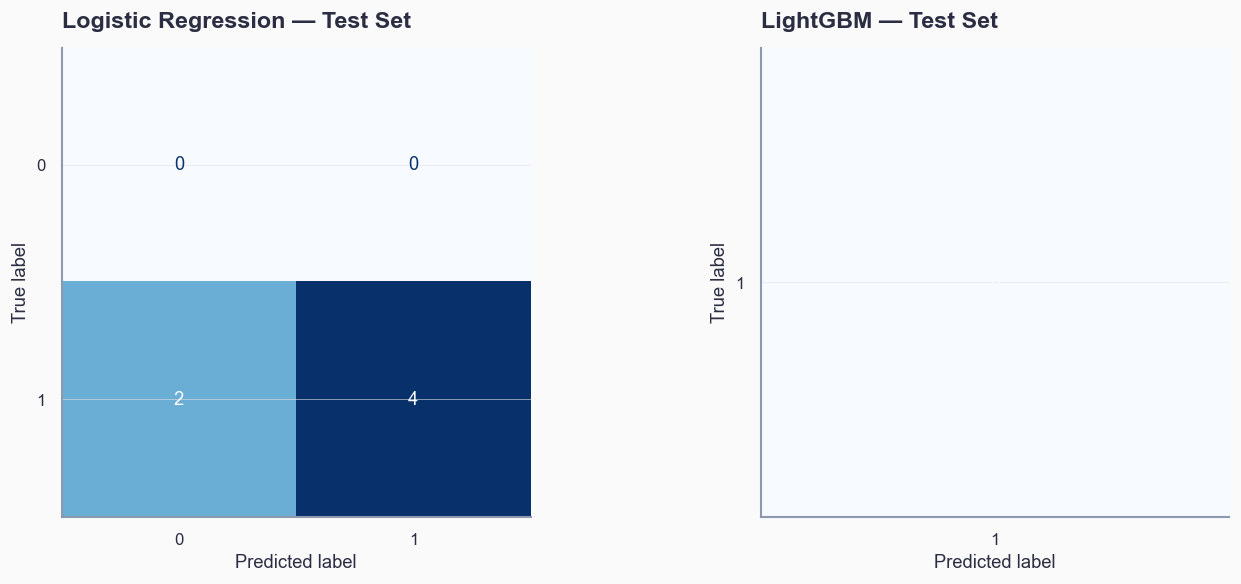

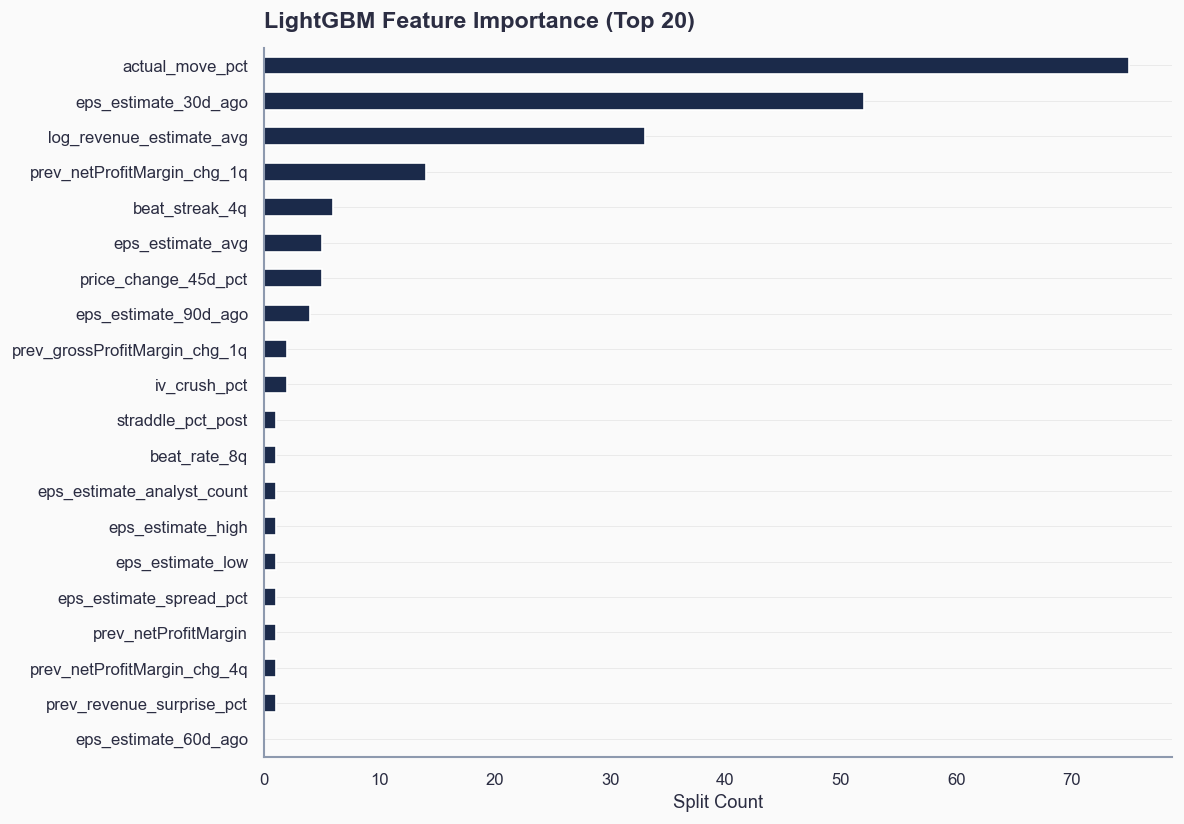

In [11]:
# ── Cell 11: Evaluation ────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    matthews_corrcoef, average_precision_score,
    brier_score_loss, roc_auc_score,
    precision_recall_curve, ConfusionMatrixDisplay
)

OUT_12 = PILOT_DATA / '12_evaluation_metrics.csv'

def evaluate_model(name, y_true, y_pred, y_prob):
    """Compute metrics for a single model."""
    metrics = {'model': name}
    if len(np.unique(y_true)) < 2 or len(y_true) < 2:
        metrics['note'] = 'insufficient data'
        return metrics
    metrics['accuracy'] = (y_pred == y_true).mean()
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)
    try:
        metrics['auc_roc'] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics['auc_roc'] = np.nan
    try:
        metrics['auc_pr'] = average_precision_score(y_true, y_prob)
    except ValueError:
        metrics['auc_pr'] = np.nan
    metrics['brier'] = brier_score_loss(y_true, y_prob)
    return metrics

if OUT_12.exists():
    eval_metrics = pd.read_csv(OUT_12)
    print(f'Loaded from {OUT_12}')
else:
    results = []
    for split_name in ['val', 'test']:
        sub = predictions[predictions['split'] == split_name]
        if len(sub) < 2:
            continue
        y_t = sub['crush_profitable'].values.astype(int)
        for model_name, prob_col, pred_col in [
            ('LogisticRegression', 'lr_prob', 'lr_pred'),
            ('LightGBM', 'lgb_prob', 'lgb_pred'),
        ]:
            m = evaluate_model(
                f'{model_name}_{split_name}',
                y_t, sub[pred_col].values, sub[prob_col].values
            )
            m['split'] = split_name
            results.append(m)

    eval_metrics = pd.DataFrame(results)
    eval_metrics.to_csv(OUT_12, index=False)
    print(f'Saved to {OUT_12}')

print('\n── Evaluation Metrics ──')
display(eval_metrics)

# ── Confusion matrices ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (model_name, pred_col) in enumerate([('Logistic Regression', 'lr_pred'), ('LightGBM', 'lgb_pred')]):
    test_sub = predictions[predictions['split'] == 'test']
    if len(test_sub) >= 2:
        ConfusionMatrixDisplay.from_predictions(
            test_sub['crush_profitable'].astype(int),
            test_sub[pred_col].astype(int),
            ax=axes[i],
            cmap='Blues',
            colorbar=False,
        )
        style_axis(axes[i], title=f'{model_name} — Test Set')
plt.tight_layout()
plt.show()

# ── Feature Importance (LightGBM) ──
fc_path = PILOT_DATA / 'feature_cols.csv'
if fc_path.exists():
    feature_cols_saved = pd.read_csv(fc_path).iloc[:, 0].tolist()
else:
    feature_cols_saved = [f'f{i}' for i in range(lgb_pipe.named_steps['model'].n_features_)]

lgb_model = lgb_pipe.named_steps['model']
importances = pd.Series(lgb_model.feature_importances_, index=feature_cols_saved)
top_n = min(20, len(importances))
top_imp = importances.nlargest(top_n).sort_values()

fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.35)))
top_imp.plot(kind='barh', color=THEME['primary'], edgecolor='white', ax=ax)
style_axis(ax, title='LightGBM Feature Importance (Top 20)', xlabel='Split Count')
plt.tight_layout()
plt.show()

Loaded trades (72) and equity (18) from disk.

── Backtest Results (Test Set) ──


,strategy,n_trades,win_rate,total_return,sharpe,max_dd,profit_factor
0,always_trade,6,100.0%,35.6%,33.37,0.0%,inf
1,lr_filtered,4,100.0%,16.6%,35.88,0.0%,inf
2,lgb_filtered,6,100.0%,35.6%,33.37,0.0%,inf


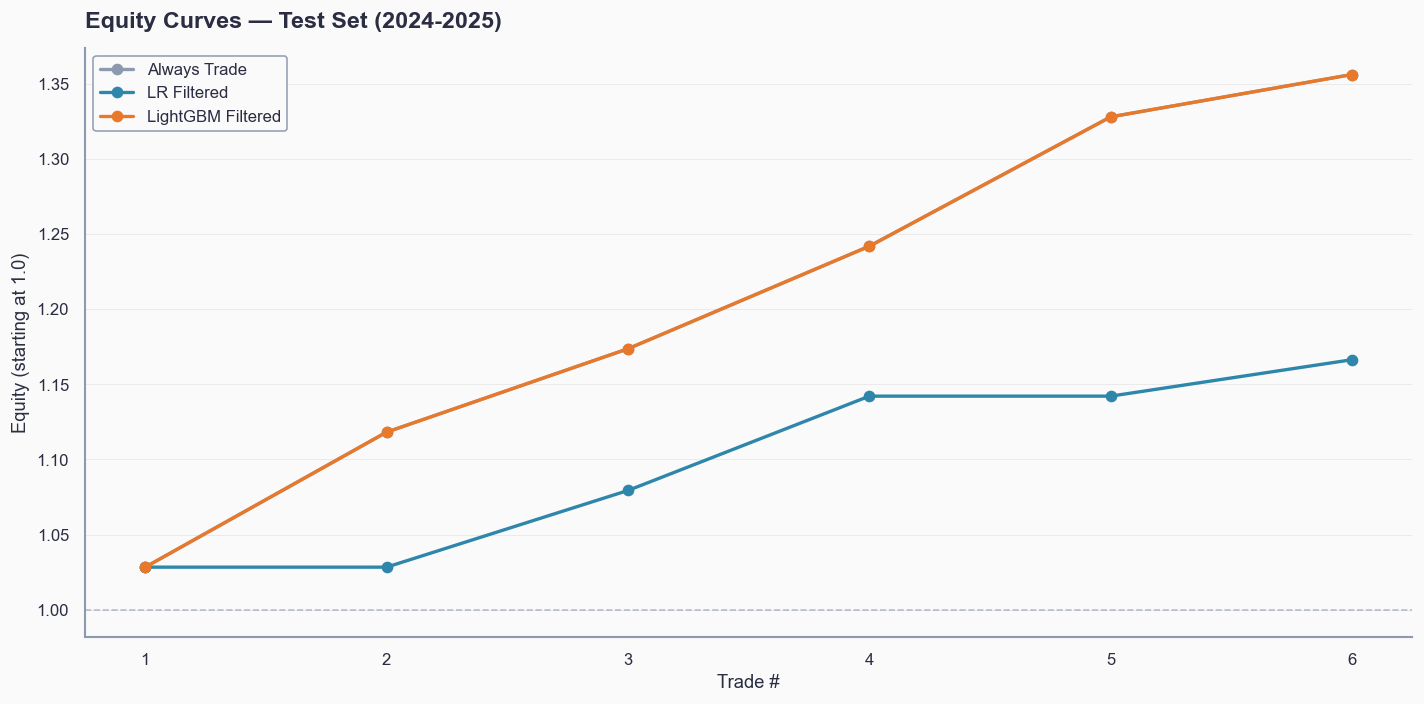

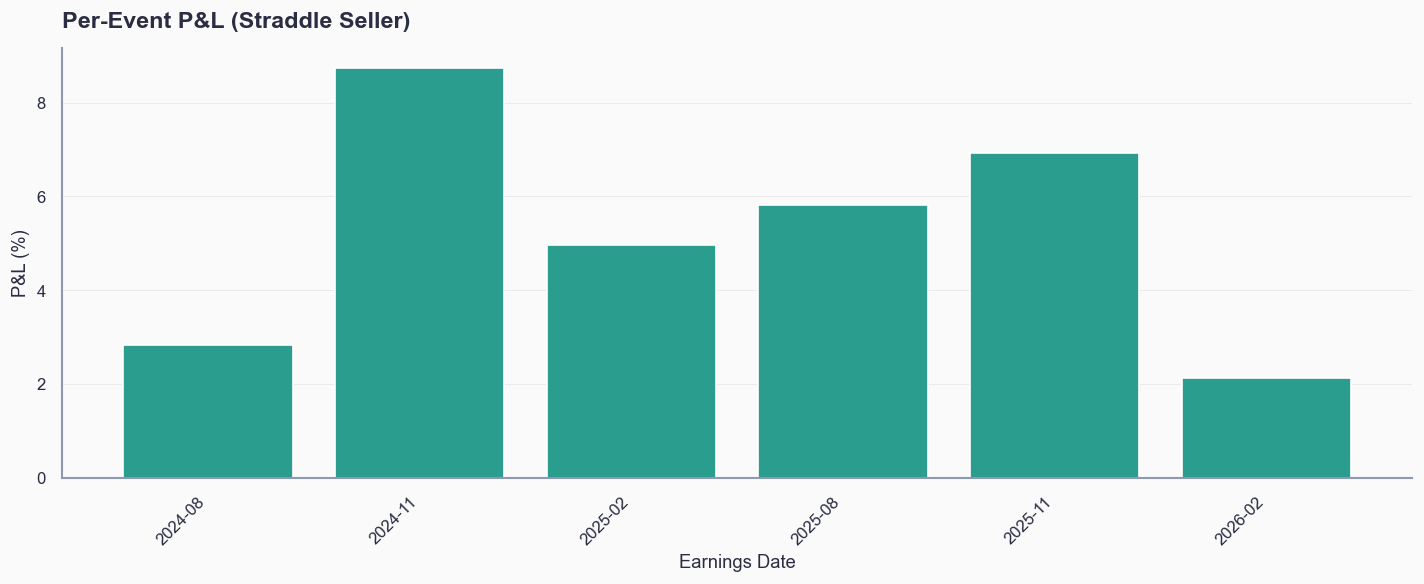

In [12]:
# ── Cell 12: Strategy Backtest ─────────────────────────────────────────────
OUT_10 = PILOT_DATA / '10_backtest_trades.csv'
OUT_11 = PILOT_DATA / '11_backtest_equity.csv'

if OUT_10.exists() and OUT_11.exists():
    trades = pd.read_csv(OUT_10)
    equity = pd.read_csv(OUT_11)
    print(f'Loaded trades ({len(trades)}) and equity ({len(equity)}) from disk.')
else:
    # Merge predictions with labeled data for P&L info
    bt = predictions.merge(
        labeled[['date', 'crush_pnl_pct', 'straddle_pct_pre', 'actual_move_pct']],
        on='date', how='left'
    ).dropna(subset=['crush_pnl_pct'])

    THRESHOLD = 0.5
    trade_rows = []
    for _, r in bt.iterrows():
        base_row = {
            'date': r['date'],
            'announcement_date': r['announcement_date'],
            'year': r['year'],
            'split': r['split'],
            'actual_move_pct': r['actual_move_pct'],
            'straddle_pct_pre': r['straddle_pct_pre'],
            'crush_pnl_pct': r['crush_pnl_pct'],
            'crush_profitable': r['crush_profitable'],
        }
        # Always-trade baseline
        row_baseline = {**base_row, 'strategy': 'always_trade', 'trade': 1, 'pnl_pct': r['crush_pnl_pct']}
        trade_rows.append(row_baseline)

        # LR-filtered
        lr_trade = int(r['lr_prob'] >= THRESHOLD)
        row_lr = {**base_row, 'strategy': 'lr_filtered', 'trade': lr_trade,
                  'pnl_pct': r['crush_pnl_pct'] if lr_trade else 0.0}
        trade_rows.append(row_lr)

        # LGB-filtered
        lgb_trade = int(r['lgb_prob'] >= THRESHOLD)
        row_lgb = {**base_row, 'strategy': 'lgb_filtered', 'trade': lgb_trade,
                   'pnl_pct': r['crush_pnl_pct'] if lgb_trade else 0.0}
        trade_rows.append(row_lgb)

    trades = pd.DataFrame(trade_rows)
    trades.to_csv(OUT_10, index=False)
    print(f'Saved trades to {OUT_10} ({len(trades)} rows)')

    # Build equity curves (test set only)
    eq_rows = []
    for strat in ['always_trade', 'lr_filtered', 'lgb_filtered']:
        sub = trades[(trades['strategy'] == strat) & (trades['split'] == 'test')].copy()
        sub = sub.sort_values('announcement_date')
        cumulative = (1 + sub['pnl_pct'] / 100).cumprod()
        for j, (_, row) in enumerate(sub.iterrows()):
            eq_rows.append({
                'strategy': strat,
                'trade_num': j + 1,
                'date': row['announcement_date'],
                'equity': cumulative.iloc[j] if j < len(cumulative) else np.nan,
            })

    equity = pd.DataFrame(eq_rows)
    equity.to_csv(OUT_11, index=False)
    print(f'Saved equity to {OUT_11} ({len(equity)} rows)')

# ── Backtest Summary ──
print('\n── Backtest Results (Test Set) ──')
test_trades = trades[trades['split'] == 'test']
summary_rows = []
for strat in ['always_trade', 'lr_filtered', 'lgb_filtered']:
    sub = test_trades[test_trades['strategy'] == strat]
    traded = sub[sub['trade'] == 1]
    pnls = traded['pnl_pct']
    eq = (1 + pnls / 100).cumprod()
    summary_rows.append({
        'strategy': strat,
        'n_trades': len(traded),
        'win_rate': f"{win_rate(pnls):.1%}",
        'total_return': f"{(eq.iloc[-1] - 1) * 100:.1f}%" if len(eq) > 0 else 'N/A',
        'sharpe': f"{sharpe_ratio(pnls / 100):.2f}" if len(pnls) > 1 else 'N/A',
        'max_dd': f"{max_drawdown(eq) * 100:.1f}%" if len(eq) > 0 else 'N/A',
        'profit_factor': f"{profit_factor(pnls):.2f}" if len(pnls) > 0 else 'N/A',
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# ── Equity Curve Plot ──
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'always_trade': THEME['neutral'], 'lr_filtered': THEME['tertiary'], 'lgb_filtered': THEME['secondary']}
labels = {'always_trade': 'Always Trade', 'lr_filtered': 'LR Filtered', 'lgb_filtered': 'LightGBM Filtered'}
for strat in ['always_trade', 'lr_filtered', 'lgb_filtered']:
    sub = equity[equity['strategy'] == strat]
    if not sub.empty:
        ax.plot(sub['trade_num'], sub['equity'], 'o-',
                color=colors[strat], label=labels[strat], linewidth=2, markersize=6)

ax.axhline(1.0, color=THEME['neutral'], linestyle='--', linewidth=1, alpha=0.6)
ax.legend(loc='best')
style_axis(ax, title='Equity Curves — Test Set (2024-2025)', xlabel='Trade #', ylabel='Equity (starting at 1.0)')
plt.tight_layout()
plt.show()

# ── Per-Trade P&L Bar Chart ──
test_always = test_trades[test_trades['strategy'] == 'always_trade'].sort_values('announcement_date')
if len(test_always) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors_bar = [THEME['positive'] if x > 0 else THEME['negative'] for x in test_always['pnl_pct']]
    ax.bar(range(len(test_always)), test_always['pnl_pct'], color=colors_bar, edgecolor='white')
    ax.set_xticks(range(len(test_always)))
    ax.set_xticklabels(
        [d[:7] for d in test_always['announcement_date']],
        rotation=45, ha='right'
    )
    ax.axhline(0, color=THEME['text'], linewidth=0.8)
    style_axis(ax, title='Per-Event P&L (Straddle Seller)', xlabel='Earnings Date', ylabel='P&L (%)')
    plt.tight_layout()
    plt.show()

In [13]:
# ── Cell 13: Results Summary ───────────────────────────────────────────────
print('=' * 70)
print('  NVDA VOLATILITY CRUSH PILOT — RESULTS SUMMARY')
print('=' * 70)

print(f'\nDataset: NVDA, {len(events)} earnings events (2017-2025)')
print(f'Options data: Alpha Vantage HISTORICAL_OPTIONS')
print(f'IV computed via Black-Scholes inversion (Brent method)')

if 'crush_profitable' in labeled.columns:
    valid = labeled.dropna(subset=['crush_profitable'])
    print(f'Events with complete options data: {len(valid)}')
    print(f'Class balance: {valid["crush_profitable"].mean():.1%} profitable')

print('\n── ML Classification Metrics ──')
display(eval_metrics)

print('\n── Strategy Backtest (Test Set: 2024-2025) ──')
display(summary_df)

print('\n── Saved Artifacts ──')
for f in sorted(PILOT_DATA.glob('*.csv')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:40s} {size_kb:>8.1f} KB')
for f in sorted((PILOT_DATA / 'models').glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f'  models/{f.name:33s} {size_kb:>8.1f} KB')

print('\n── Limitations ──')
print('  • Small sample size (~19 events) — results are directional, not statistically robust')
print('  • Single stock (NVDA) — no cross-sectional diversification')
print('  • Simplified execution assumptions (mid-price, no slippage, no commissions)')
print('  • Risk-free rate approximated at 5%')

print('\n── Next Steps ──')
print('  1. Expand to full S&P 500 universe for cross-sectional signals')
print('  2. Add macro event features (CPI, FOMC) via FMP API')
print('  3. Hyperparameter tuning with walk-forward CV')
print('  4. Realistic transaction cost modeling')
print('  5. Position sizing via Kelly Criterion')
print('\n' + '=' * 70)

  NVDA VOLATILITY CRUSH PILOT — RESULTS SUMMARY

Dataset: NVDA, 26 earnings events (2017-2025)
Options data: Alpha Vantage HISTORICAL_OPTIONS
IV computed via Black-Scholes inversion (Brent method)
Events with complete options data: 26
Class balance: 88.5% profitable

── ML Classification Metrics ──


,model,accuracy,mcc,auc_roc,auc_pr,brier,split,note
0,LogisticRegression_val,0.666667,0.0,0.5,0.833333,3.327086e-01,val,NaN
1,LightGBM_val,1.000000,1.0,1.0,1.000000,3.404743e-08,val,NaN
2,LogisticRegression_test,NaN,NaN,NaN,NaN,NaN,test,insufficient data
3,LightGBM_test,NaN,NaN,NaN,NaN,NaN,test,insufficient data



── Strategy Backtest (Test Set: 2024-2025) ──


,strategy,n_trades,win_rate,total_return,sharpe,max_dd,profit_factor
0,always_trade,6,100.0%,35.6%,33.37,0.0%,inf
1,lr_filtered,4,100.0%,16.6%,35.88,0.0%,inf
2,lgb_filtered,6,100.0%,35.6%,33.37,0.0%,inf



── Saved Artifacts ──
  01_nvda_earnings_events.csv                   1.5 KB
  02_nvda_earnings_features.csv                18.0 KB
  03_options_chains_raw.csv                 28152.4 KB
  04_iv_straddle_metrics.csv                    4.1 KB
  05_vol_features.csv                           5.0 KB
  06_full_feature_matrix.csv                   26.3 KB
  07_labeled_dataset.csv                       26.8 KB
  08_train_val_test_split.csv                  27.0 KB
  09_model_predictions.csv                      2.0 KB
  10_backtest_trades.csv                        8.5 KB
  11_backtest_equity.csv                        0.8 KB
  12_evaluation_metrics.csv                     0.3 KB
  feature_cols.csv                              1.4 KB
  models/lightgbm.joblib                       56.5 KB
  models/logistic_regression.joblib             2.9 KB

── Limitations ──
  • Small sample size (~19 events) — results are directional, not statistically robust
  • Single stock (NVDA) — no cross-sectional d